# Chapter 2: Data and Sampling Distributions

## 1. Summary / Ringkasan Bab
Bab ini membahas konsep dasar penting dalam statistik inferensial dan machine learning, yaitu bagaimana sampel diambil dari populasi dan bagaimana distribusi sampling bekerja. Fokus utamanya adalah memahami Teorema Limit Terpusat (Central Limit Theorem), teknik resampling Bootstrap untuk mengukur ketidakpastian, Sela Kepercayaan (Confidence Intervals), serta berbagai bentuk distribusi data statistik.

## 2. Theoretical Deep-Dive
- **Random Sampling & Selection Bias**:
  - *Random Sampling*: Pengambilan sampel secara acak agar sampel mewakili (representatif terhadap) populasi.
  - *Selection Bias*: Bias yang terjadi jika sampel tidak dipilih secara acak merata.
- **Central Limit Theorem (CLT) & Standard Error**:
  - *CLT*: Menyatakan bahwa distribusi rata-rata dari banyak sampel acak akan mendekati Distribusi Normal, berapa pun bentuk distribusi populasinya.
  - *Standard Error (SE)*: Mengukur variabilitas rata-rata sampel antar sampel yang berbeda.
- **Bootstrap & Confidence Intervals**:
  - *Bootstrap*: Teknik resampling dengan pengembalian (with replacement) untuk memperkirakan statistik sampel tanpa asumsi distribusi tertentu.
  - *Confidence Interval*: Rentang nilai yang diperkirakan mencakup parameter populasi sebenarnya dengan tingkat kepercayaan tertentu (misal 95%).

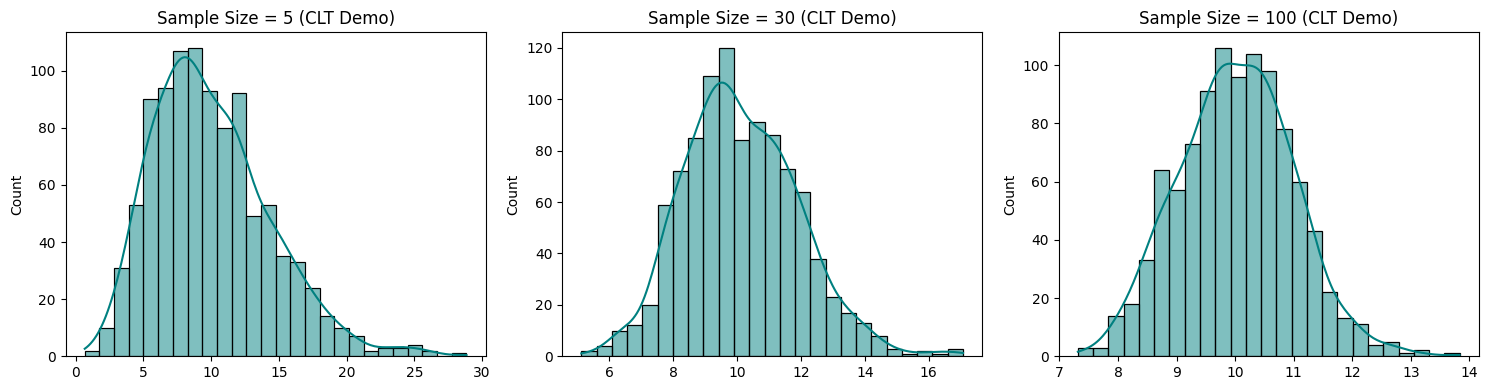

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Simulasi Populasi & Central Limit Theorem (CLT)
np.random.seed(42)
# Populasi berbuntut panjang (Exponential distribution)
population = np.random.exponential(scale=10, size=100000)

# Mengambil sampel berulang kali untuk membuktikan CLT
sample_sizes = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, size in enumerate(sample_sizes):
    sample_means = [np.mean(np.random.choice(population, size=size)) for _ in range(1000)]
    sns.histplot(sample_means, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Sample Size = {size} (CLT Demo)')

plt.tight_layout()
plt.show()

=== BOOTSTRAP RESAMPLING RESULTS ===
Sample Mean             : 11.73
Bootstrap Mean          : 11.66
95% Confidence Interval : [9.63, 13.92]


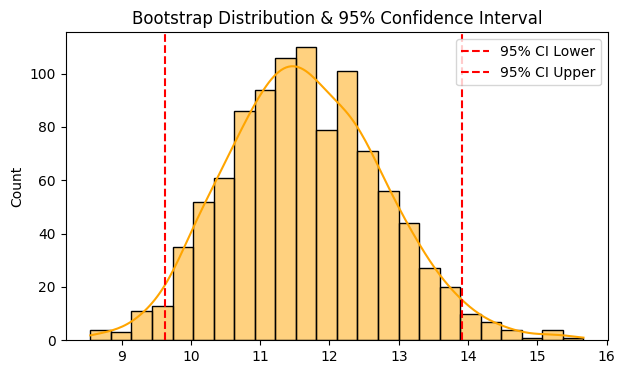

In [2]:
# 2. Bootstrap Resampling & Confidence Interval (95%)
sample_data = np.random.choice(population, size=100)

# Generasi 1000 sampel bootstrap
bootstrap_means = [np.mean(np.random.choice(sample_data, size=len(sample_data), replace=True)) for _ in range(1000)]

# Menghitung Confidence Interval 95%
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("=== BOOTSTRAP RESAMPLING RESULTS ===")
print(f"Sample Mean             : {np.mean(sample_data):.2f}")
print(f"Bootstrap Mean          : {np.mean(bootstrap_means):.2f}")
print(f"95% Confidence Interval : [{ci_lower:.2f}, {ci_upper:.2f}]")

# Visualisasi Distribusi Bootstrap
plt.figure(figsize=(7, 4))
sns.histplot(bootstrap_means, kde=True, color='orange')
plt.axvline(ci_lower, color='red', linestyle='--', label='95% CI Lower')
plt.axvline(ci_upper, color='red', linestyle='--', label='95% CI Upper')
plt.title('Bootstrap Distribution & 95% Confidence Interval')
plt.legend()
plt.show()